<a href="https://colab.research.google.com/github/ldaniel-hm/eml_tabular/blob/main/MonteCarloTodasLasVisitas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Monte carlo con Políticas epsilon-greddy**

In [1]:
%%capture
#@title Instalamos gym
!pip install 'gym[box2d]==0.20.0'
!pip install "gymnasium[toy-text]

In [2]:
import sys

if "google.colab" in sys.modules:
    print("Google Colab")
    !git clone #TODO
    %cd k_brazos/PATH_CLONADO #TODO

sys.path.append("src")
print(sys.path)

['C:\\Users\\Alberto\\anaconda3\\envs\\EML\\python311.zip', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML\\DLLs', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML\\Lib', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML', '', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML\\Lib\\site-packages', 'src']


In [3]:
#@title Importamos librerias
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
from agent.monte_carlo_on_policy import MonteCarloOnPolicy
from plotting import plot_stats, plot_episode_lengths
from IPython.display import clear_output
import time

In [4]:
seed = 123 # Se define una semilla fija
# Fijar la semilla en NumPy
np.random.seed(seed) # Para generar números aleatorios consistentes en NumPy
np.random.default_rng(seed) # Establece una instancia del generador de NumPy con la misma semilla

Generator(PCG64) at 0x2028999A260

In [5]:
# is_rainy=False evita ruido en los movimientos
# fickle_passenger=False para omitir un cambio de destino sobre las marcha del pasajero
env = gym.make("Taxi-v4", is_rainy=False, fickle_passenger=False, render_mode="rgb_array") 

num_episodes = 50000

mc_agent = MonteCarloOnPolicy(env=env, initial_epsilon=1.0, epsilon_decay=0.00005, final_epsilon=0.20, discount_factor=1)


episode_lengths = []
list_stats = []

for episode in tqdm(range(num_episodes)):
    state, _ = env.reset(seed=seed)
    done = False
    
    episode_reward = 0
    episode_length = 0
    
    while not done:
        action = mc_agent.get_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        mc_agent.update(state, next_state, action, reward, terminated, truncated)
        state = next_state
        
        done = terminated or truncated
        episode_reward += reward
        episode_length += 1
    
    # Fin de episodio
    mc_agent.end_episode()
    mc_agent.decay_exploration()

    # Se guardan los promedios y la longitud del episodio para las gráficas posteriores
    list_stats.append(episode_reward)
    episode_lengths.append(episode_length)

    if episode % 5000 == 0 and episode != 0:
        print(f"Recompensa del episodio: {episode_reward:.2f}, epsilon: {mc_agent.epsilon:.3f}")

 10%|███████▊                                                                    | 5170/50000 [00:18<01:21, 550.66it/s]

Recompensa del episodio: -79.00, epsilon: 0.750


 21%|███████████████▏                                                          | 10264/50000 [00:25<00:34, 1146.50it/s]

Recompensa del episodio: -61.00, epsilon: 0.500


 31%|██████████████████████▋                                                   | 15316/50000 [00:28<00:18, 1848.87it/s]

...

 81%|███████████████████████████████████████████████████████████▊              | 40389/50000 [00:41<00:04, 2040.12it/s]

Recompensa del episodio: -30.00, epsilon: 0.200


 90%|██████████████████████████████████████████████████████████████████▉       | 45220/50000 [00:44<00:02, 1894.48it/s]

Recompensa del episodio: -33.00, epsilon: 0.200


100%|██████████████████████████████████████████████████████████████████████████| 50000/50000 [00:46<00:00, 1064.11it/s]


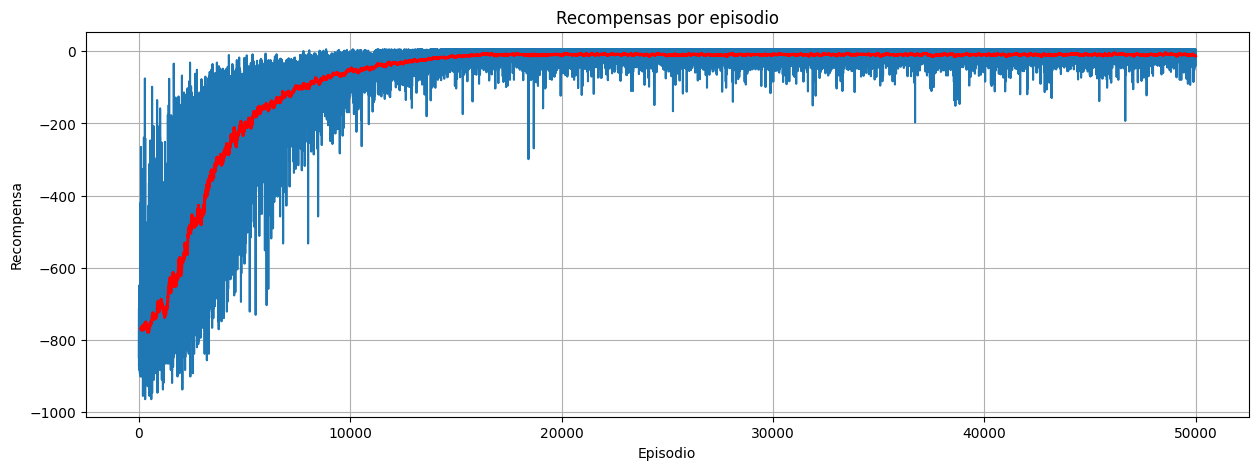

Máxima proporcion: 6


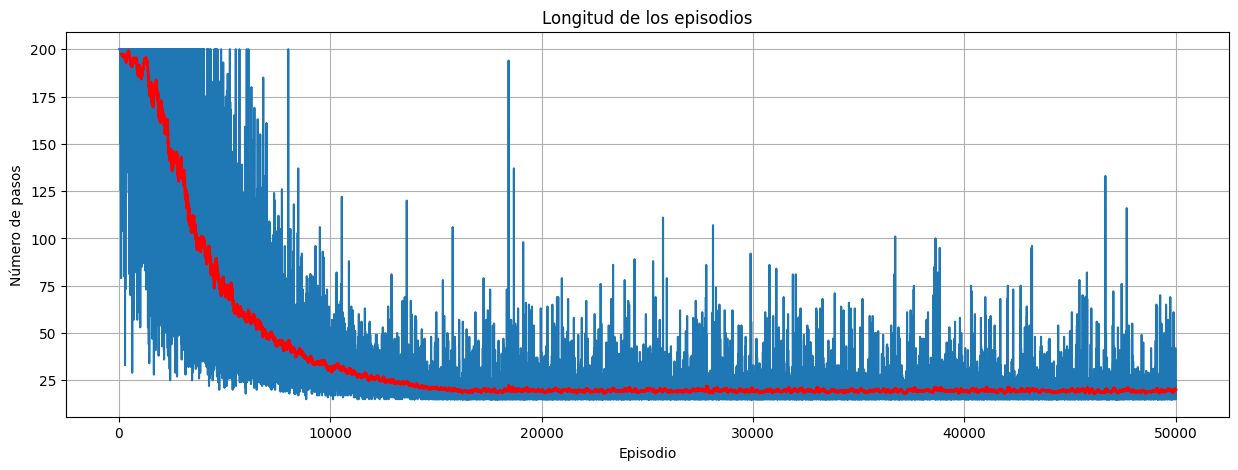

In [6]:
plot_stats(list_stats)
print(f"Máxima proporcion: {max(list_stats)}")
plot_episode_lengths(episode_lengths)

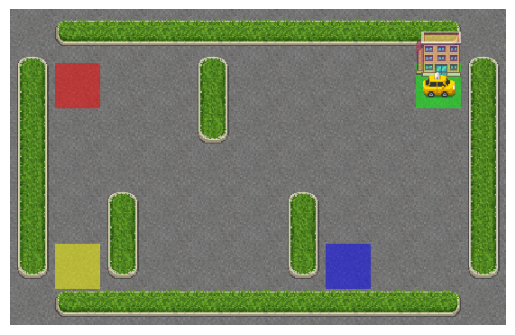

Reward final: 6
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


Acciones: WEST -> NORTH -> NORTH -> WEST -> NORTH -> PICKUP -> SOUTH -> SOUTH -> EAST -> EAST -> NORTH -> NORTH -> EAST -> EAST -> DROPOFF


In [7]:
state, _ = env.reset(seed=seed)
ACTION_NAMES = {0: "SOUTH", 1: "NORTH", 2: "EAST", 3: "WEST", 4: "PICKUP", 5: "DROPOFF"}

actions_taken = []

done = False
rewards = 0

while not done:
    frame = env.render()

    clear_output(wait=True)
    plt.imshow(frame)
    plt.axis("off")
    plt.show()

    action = mc_agent.get_action(state, training=False) # training False asegura np.argmax(self.q_values[state])
    actions_taken.append(ACTION_NAMES[action])

    state, reward, terminated, truncated, _ = env.step(action)
    rewards += reward

    done = terminated or truncated

    time.sleep(0.25)

print("Reward final:", rewards)
# Mostramos la representación real que la visual puede confundir
env_ansi = gym.make("Taxi-v4", render_mode="ansi")
state, _ = env_ansi.reset(seed=seed)
print(env_ansi.render())
print("Acciones:", " -> ".join(actions_taken))